# Dataset Annotation Figures

Generates PDF figures for the appendix from `Jazhyc/aims-safety-intents`.

**Outputs** (`report/latex/img/`):
- `annotator_agreement_heatmap.pdf` — inter-annotator agreement on the four-point harm scale
- `intent_length_distribution.pdf` — distribution of intent description lengths

In [1]:
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import concatenate_datasets, load_dataset
from sklearn.metrics import confusion_matrix

OUTPUT_DIR = Path("../../report/latex/img")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
ds = concatenate_datasets([
    load_dataset("Jazhyc/aims-safety-intents", split="train"),
    load_dataset("Jazhyc/aims-safety-intents", split="validation"),
    load_dataset("Jazhyc/aims-safety-intents", split="test"),
])
df = ds.to_pandas().dropna(subset=["Annotator Harm"])

dup_df = df.groupby("Prompt").filter(lambda g: len(g) > 1)
n_prompts = dup_df["Prompt"].nunique()
print(f"Duplicate prompts: {n_prompts}, total annotations: {len(dup_df)}")

Duplicate prompts: 225, total annotations: 674


In [3]:
HARM_LABELS = [
    "Completely Harmful",
    "Uncertain Harmful",
    "Uncertain Safe",
    "Completely Safe",
]

# Build symmetric pairwise label comparisons within each duplicate group
pairs = []
for _, group in dup_df.groupby("Prompt"):
    labels = group["Annotator Harm"].tolist()
    for a, b in combinations(labels, 2):
        pairs.append((a, b))
        pairs.append((b, a))

pair_df = pd.DataFrame(pairs, columns=["Annotator A", "Annotator B"])
print(f"Unique pairs: {len(pairs) // 2}, symmetric entries: {len(pairs)}")

Unique pairs: 945, symmetric entries: 1890


Saved ../../report/latex/img/annotator_agreement_heatmap.pdf


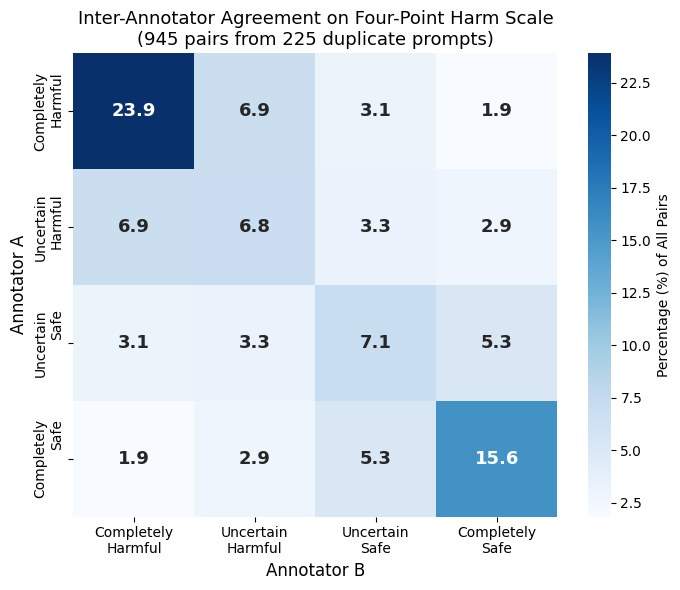

In [4]:
DISPLAY_LABELS = [
    "Completely\nHarmful",
    "Uncertain\nHarmful",
    "Uncertain\nSafe",
    "Completely\nSafe",
]

cm = confusion_matrix(
    pair_df["Annotator A"],
    pair_df["Annotator B"],
    labels=HARM_LABELS,
)
cm_pct = cm / cm.sum() * 100

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_pct,
    annot=True,
    fmt=".1f",
    xticklabels=DISPLAY_LABELS,
    yticklabels=DISPLAY_LABELS,
    cmap="Blues",
    annot_kws={"fontsize": 13, "fontweight": "bold"},
    cbar_kws={"label": "Percentage (%) of All Pairs"},
    ax=ax,
)
ax.set_xlabel("Annotator B", fontsize=12)
ax.set_ylabel("Annotator A", fontsize=12)
ax.set_title(
    f"Inter-Annotator Agreement on Four-Point Harm Scale\n"
    f"({len(pairs) // 2:,} pairs from {n_prompts} duplicate prompts)",
    fontsize=13,
)
fig.tight_layout()

out = OUTPUT_DIR / "annotator_agreement_heatmap.pdf"
fig.savefig(out, bbox_inches="tight")
print(f"Saved {out}")
plt.show()

In [ ]:
intent_lengths = df.dropna(subset=["Intent"])["Intent"].str.split().str.len()

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(intent_lengths, bins=range(1, intent_lengths.max() + 2), edgecolor="white", linewidth=0.5)
ax.axvline(intent_lengths.median(), color="black", linestyle="--", linewidth=1, label=f"Median ({intent_lengths.median():.0f})")
ax.set_xlabel("Intent Length (words)", fontsize=12)
ax.set_ylabel("Number of Prompts", fontsize=12)
ax.set_title(f"Distribution of Intent Description Lengths (n={len(intent_lengths):,})", fontsize=13)
ax.legend()
fig.tight_layout()

out = OUTPUT_DIR / "intent_length_distribution.pdf"
fig.savefig(out, bbox_inches="tight")
print(f"Saved {out}")
plt.show()